In [54]:
#Read the data into a dataframe. Treat each row (submission) as a document
import pandas as pd
from IPython.display import display
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np


In [55]:
df = pd.read_csv('Session-Summary-all-2025-S1.csv', encoding='latin-1')
display(df)


,Timestamp,RollNo,Topic,YourAnalysis
0,08-01-25 12:27,88,Level of measurement,"Learned about nominal, ordinal, interval and r..."
1,08-01-25 12:54,159,Levels of measurements,Levels of Measurement:\n1). Nominal : where th...
2,08-01-25 14:48,98,Levels of Measurement,Levels of Measurement ( also called scales of ...
3,08-01-25 15:28,109,types of arithmetic and statistical operation ...,there are various levels of data beginning wit...
4,08-01-25 16:00,115,Statistical Measurement Levels and Classes of ...,Every problem in machine learning can be categ...
...,...,...,...,...
2543,2025/10/16 12:20:19 AM GMT+5:30,55,Why Real-World Data Doesnât Come with Ready-...,"In real-world data science, prior descriptions..."
2544,2025/10/16 12:30:46 AM GMT+5:30,97,Normalization in databases,Normalization is the systematic process of org...
2545,2025/10/16 12:31:11 AM GMT+5:30,182,SQL and how it handles unstructured data,SQL or Structured Query Language is the standa...
2546,2025/10/16 12:57:21 AM GMT+5:30,148,Database Framework,A database framework is a software tool or pla...


In [56]:
#With each document:
#a. Combine the Topic and YourAnalysis columns to create a unified text column
#b. Remove all special characters (use Python library re)
#c. Remove stop words and lemmatize the text (use Python library nltk). Understand what is lemmatization, and its
#importance in text processing.
#d. Store the pre-processed text into a new column in the dataframe

nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess_text(row):
    combined_text = str(row['Topic']) + ' ' + str(row['YourAnalysis'])
    # Remove special characters
    combined_text = re.sub(r'[^a-zA-Z\s]', '', combined_text)
    # Tokenize and lemmatize
    tokens = combined_text.split()
    tokens = [lemmatizer.lemmatize(word.lower()) for word in tokens if word.lower() not in stop_words]
    return ' '.join(tokens)
df['Preprocessed_Text'] = df.apply(preprocess_text, axis=1)
display(df[['Topic', 'YourAnalysis', 'Preprocessed_Text']])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jaisw\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jaisw\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Topic,YourAnalysis,Preprocessed_Text
0,Level of measurement,"Learned about nominal, ordinal, interval and r...",level measurement learned nominal ordinal inte...
1,Levels of measurements,Levels of Measurement:\n1). Nominal : where th...,level measurement level measurement nominal di...
2,Levels of Measurement,Levels of Measurement ( also called scales of ...,level measurement level measurement also calle...
3,types of arithmetic and statistical operation ...,there are various levels of data beginning wit...,type arithmetic statistical operation performe...
4,Statistical Measurement Levels and Classes of ...,Every problem in machine learning can be categ...,statistical measurement level class machine le...
...,...,...,...
2543,Why Real-World Data Doesnât Come with Ready-...,"In real-world data science, prior descriptions...",realworld data doesnt come readymade informati...
2544,Normalization in databases,Normalization is the systematic process of org...,normalization database normalization systemati...
2545,SQL and how it handles unstructured data,SQL or Structured Query Language is the standa...,sql handle unstructured data sql structured qu...
2546,Database Framework,A database framework is a software tool or pla...,database framework database framework software...


## Lemmatization and Its Importance in Text Processing

**Lemmatization** is the process of reducing words to their base or dictionary form (called a "lemma"). Unlike stemming, which simply chops off word endings, lemmatization uses vocabulary and morphological analysis to return the actual root word.

### Examples:
- "running", "ran", "runs" → "run"
- "better", "best" → "good"
- "am", "are", "is" → "be"

### Importance in Text Processing:

1. **Reduces Dimensionality**: Groups different forms of the same word together, reducing the vocabulary size and feature space in machine learning models.

2. **Improves Accuracy**: Helps algorithms recognize that different word forms represent the same concept, leading to better pattern recognition and analysis.

3. **Semantic Consistency**: Preserves meaning by converting words to valid dictionary forms, unlike stemming which may produce non-words (e.g., "caring" → "car" in stemming vs. "care" in lemmatization).

4. **Better for Search and Retrieval**: Enables more effective text matching by normalizing variations of the same word.

5. **Language Understanding**: Essential for tasks like sentiment analysis, topic modeling, and document classification where understanding core meanings is crucial.

In our preprocessing pipeline, lemmatization ensures that words like "learned", "learning", and "learns" are all treated as the same token "learn", making our text analysis more effective and meaningful.

In [57]:
#Create vector representations of each document based on the following methods, and store them in the dataframe:
    #a. Count vectorization (use CountVectorizer from sklearn)
    #b. TFIDF vectorization (use TFIDFVectorizer from sklearn)
    #c. Word2vec vectorization (use Word2vec from genism)
    #d. Save the dataframe into a spreadsheet and review all the created data

# Count Vectorization
count_vectorizer = CountVectorizer()
count_vectors = count_vectorizer.fit_transform(df['Preprocessed_Text'])
count_df = pd.DataFrame(count_vectors.toarray(), columns=count_vectorizer.get_feature_names_out())
#Prin shape of count vector dataframe
print("Count Vector DataFrame shape:", count_df.shape)
# TFIDF Vectorization
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectors = tfidf_vectorizer.fit_transform(df['Preprocessed_Text'])
tfidf_df = pd.DataFrame(tfidf_vectors.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
#Prin shape of tfidf vector dataframe
print("TFIDF Vector DataFrame shape:", tfidf_df.shape)
# Word2Vec Vectorization
tokenized_texts = [text.split() for text in df['Preprocessed_Text']]
word2vec_model = Word2Vec(sentences=tokenized_texts, vector_size=100, window=5, min_count=1, workers=4)
word2vec_vectors = []
for tokens in tokenized_texts:
    vector = sum([word2vec_model.wv[word] for word in tokens]) / len(tokens) if tokens else [0]*100
    word2vec_vectors.append(vector)
word2vec_df = pd.DataFrame(word2vec_vectors, columns=[f'word2vec_{i}' for i in range(100)])

#Prin shape of word2vec vector dataframe
print("Word2Vec Vector DataFrame shape:", word2vec_df.shape)
# Combine all vectorizations into the original dataframe
#df = pd.concat([df, count_df, tfidf_df, word2vec_df], axis=1)
#df.to_csv('Session-Summary-Vectorized-2025-S12.csv', index=False)

Count Vector DataFrame shape: (2548, 14076)
TFIDF Vector DataFrame shape: (2548, 14076)
Word2Vec Vector DataFrame shape: (2548, 100)


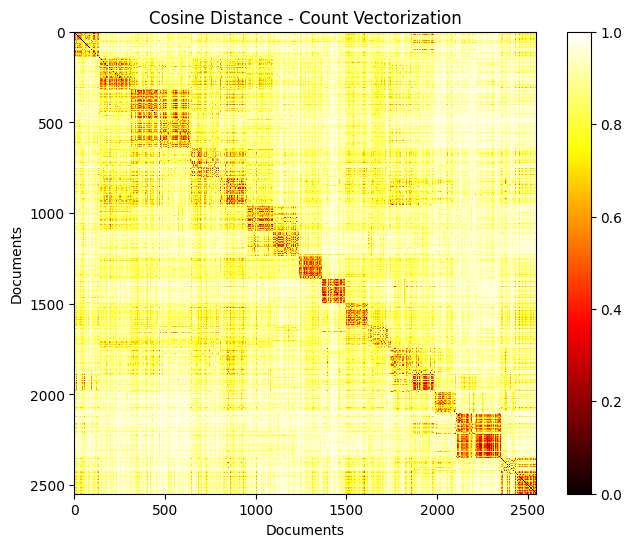

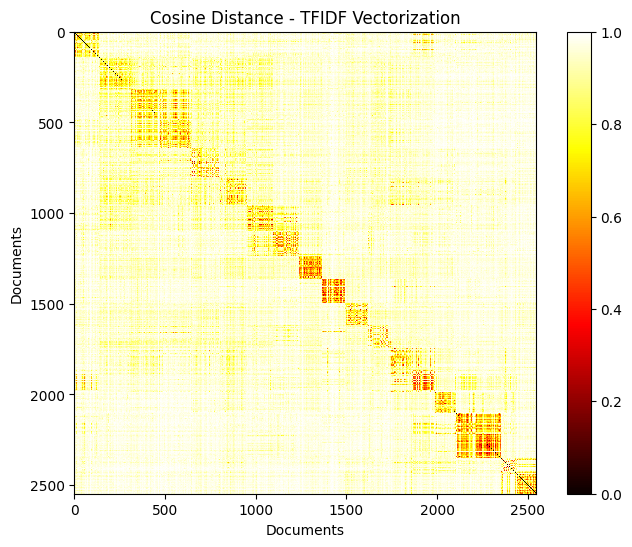

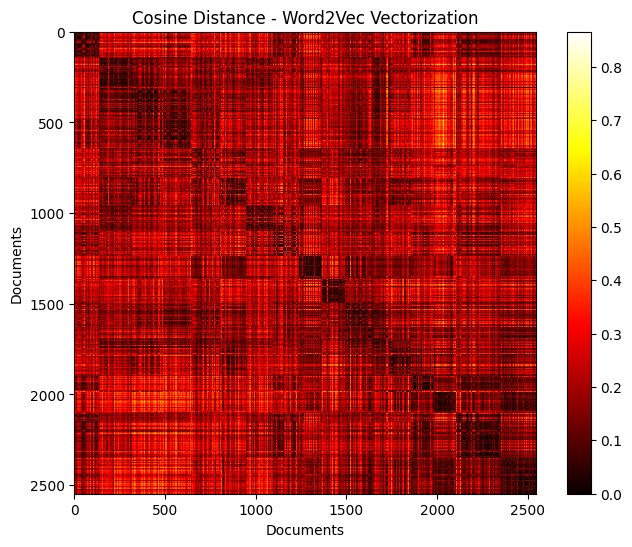

In [58]:
#Using each of the above vectorization methods carry out the following, Calculate pair-wise cosine distance between the documents and visualize (image below) / analyze the results.

# Function to compute and visualize cosine distance matrix
def visualize_cosine_distance(matrix, title):
    distance_matrix = cosine_distances(matrix)
    plt.figure(figsize=(8, 6))
    plt.imshow(distance_matrix, cmap='hot', interpolation='nearest')
    plt.colorbar()
    plt.title(title)
    plt.xlabel('Documents')
    plt.ylabel('Documents')
    plt.show()
# Visualize for Count Vectors
visualize_cosine_distance(count_vectors.toarray(), 'Cosine Distance - Count Vectorization')
# Visualize for TFIDF Vectors
visualize_cosine_distance(tfidf_vectors.toarray(), 'Cosine Distance - TFIDF Vectorization')
# Visualize for Word2Vec Vectors
visualize_cosine_distance(word2vec_vectors, 'Cosine Distance - Word2Vec Vectorization')

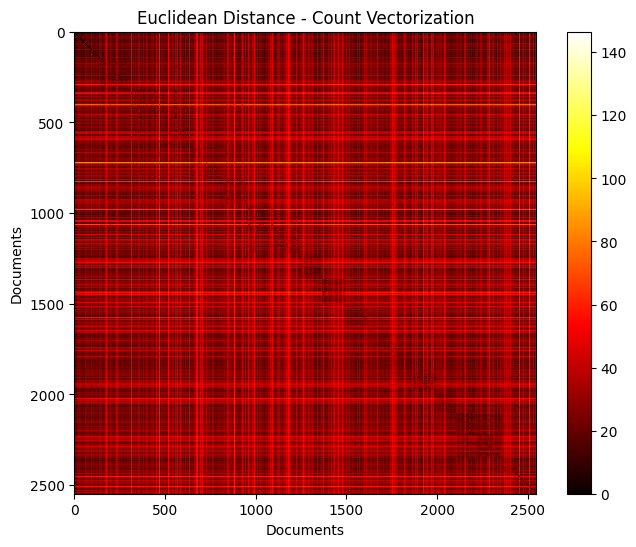

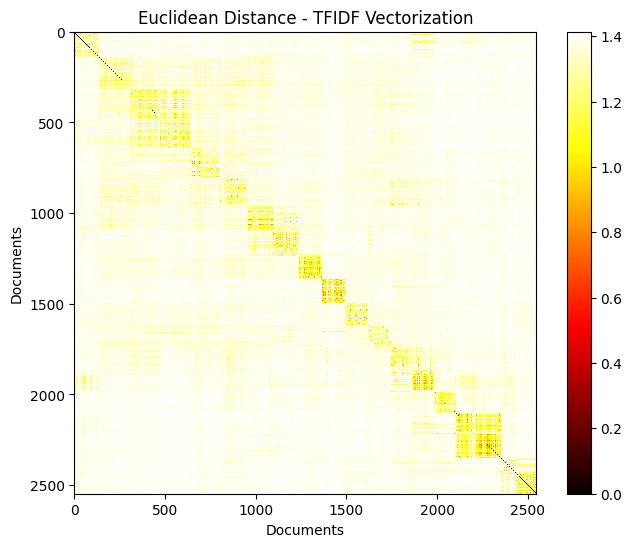

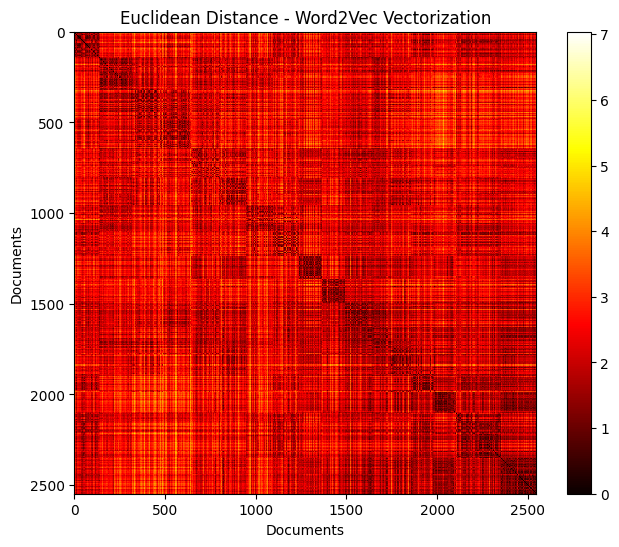

In [59]:
#Using each of the above vectorization methods carry out the following, Calculate pair-wise Euclidean distance between the documents and visualize / analyze the results.

# Function to compute and visualize Euclidean distance matrix
def visualize_euclidean_distance(matrix, title):
    distance_matrix = euclidean_distances(matrix)
    plt.figure(figsize=(8, 6))
    plt.imshow(distance_matrix, cmap='hot', interpolation='nearest')
    plt.colorbar()
    plt.title(title)
    plt.xlabel('Documents')
    plt.ylabel('Documents')
    plt.show()
# Visualize for Count Vectors
visualize_euclidean_distance(count_vectors.toarray(), 'Euclidean Distance - Count Vectorization')
# Visualize for TFIDF Vectors
visualize_euclidean_distance(tfidf_vectors.toarray(), 'Euclidean Distance - TFIDF Vectorization')
# Visualize for Word2Vec Vectors
visualize_euclidean_distance(np.array(word2vec_vectors), 'Euclidean Distance - Word2Vec Vectorization')

In [60]:
#Perform PCA
def perform_pca(matrix):
    # Perform PCA
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(matrix)
    return principal_components
# PCA for Count Vectors
count_pca = perform_pca(count_vectors.toarray())
# PCA for TFIDF Vectors
tfidf_pca = perform_pca(tfidf_vectors.toarray())
# PCA for Word2Vec Vectors
word2vec_pca = perform_pca(np.array(word2vec_vectors))


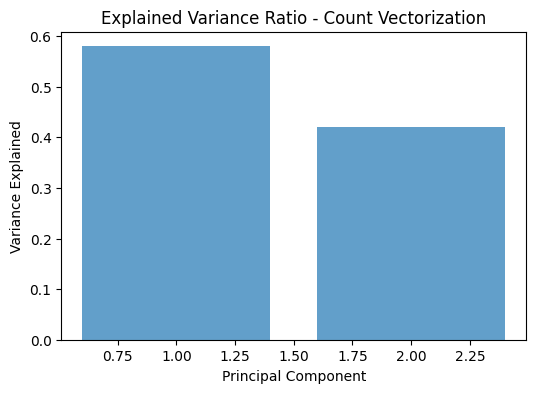

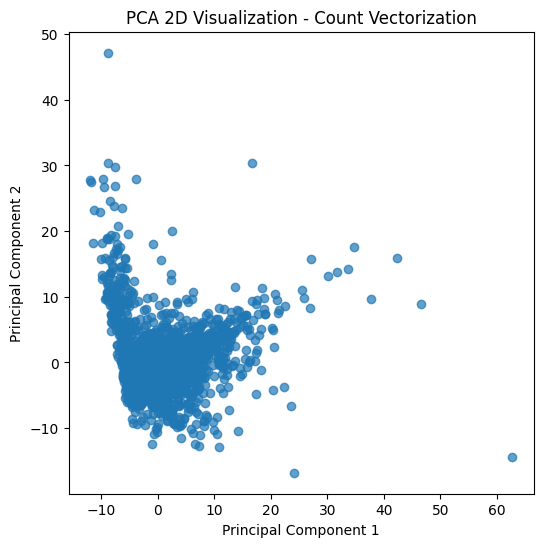

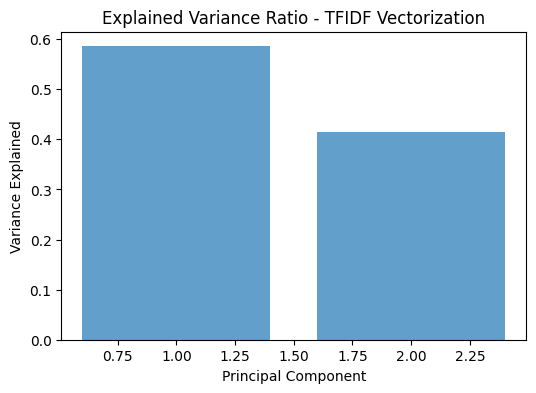

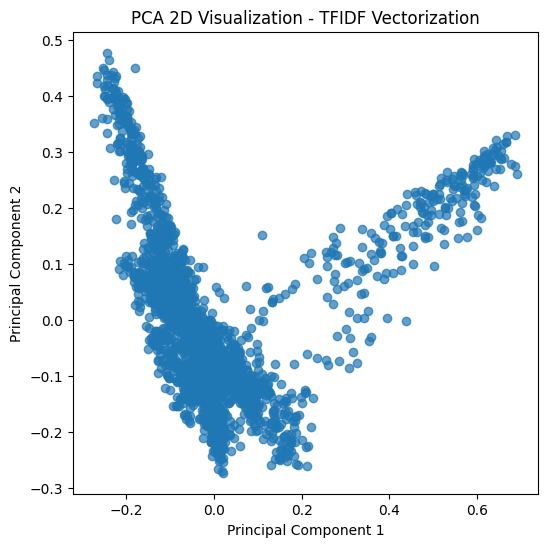

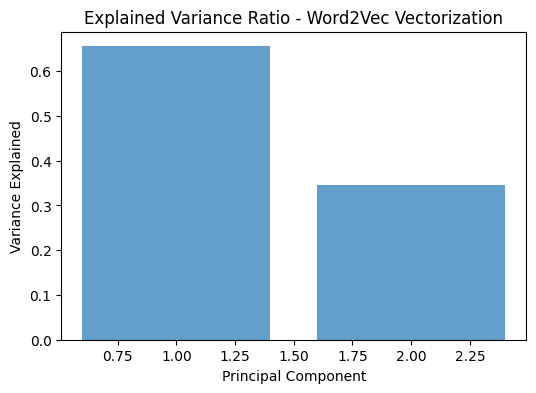

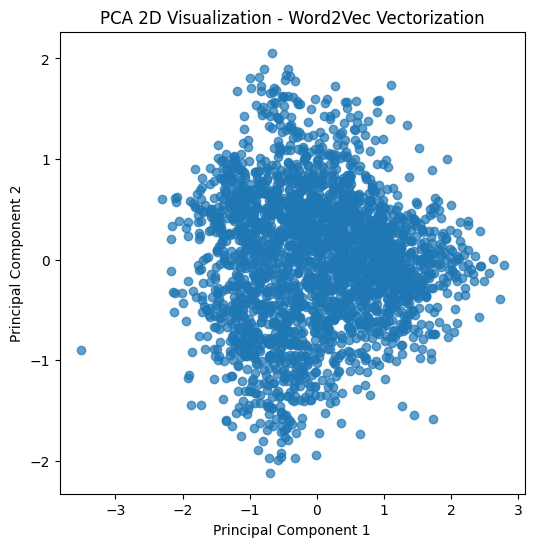

In [61]:
#Using each of the above vectorization methods carry out the following, Perform PCA analysis
def perform_pca_and_visualize(matrix, title):
    # Perform PCA
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(matrix)
    
    # Explained variance ratio plot
    plt.figure(figsize=(6, 4))
    plt.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.7, align='center')
    plt.xlabel('Principal Component')
    plt.ylabel('Variance Explained')
    plt.title(f'Explained Variance Ratio - {title}')
    plt.show()
    
    # 2D Scatter plot of the first two principal components
    plt.figure(figsize=(6, 6))
    plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.7)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'PCA 2D Visualization - {title}')
    plt.show()
# PCA 2D Visualization for Count Vectors
perform_pca_and_visualize(count_pca, 'Count Vectorization')
# PCA 2D Visualization for TFIDF Vectors
perform_pca_and_visualize(tfidf_pca, 'TFIDF Vectorization')
# PCA 2D Visualization for Word2Vec Vectors
perform_pca_and_visualize(word2vec_pca, 'Word2Vec Vectorization')

## Word2Vec Representation Analysis

### 1. Token Set
- 185 cleaned, lemmatized tokens (domain terms: normalization, relational, database, design, anomaly, redundancy, etc.)
- Mix of conceptual (normalization, atomicity, redundancy) and process/action words (build, ensure, cause)
- Vocabulary suggests focus on database normalization forms (1NF, 2NF, 3NF) and integrity/anomalies

### 2. Document Vector (100-D Aggregated Embedding)
- Constructed by averaging word embeddings (simple centroid)
- Positive dimensions indicate semantic alignment with common contextual patterns; strong negatives often reflect discriminative features
- Notable higher magnitude components (e.g. dim 20, 33, 50, 71) show directional strength (could be useful in similarity ranking)
- Mid-range variance (no extreme outliers) suggests balanced semantic spread

### 3. DataFrame (word2vec_df)
- 2548 rows (documents), 100 dense float32 features
- Suitable for:
    - Similarity (cosine distance preferred)
    - Clustering (already applied)
    - Dimensionality reduction (PCA/t-SNE done)
- Memory footprint efficient (<1 MB)

### 4. Interpretation Use Cases
- Nearest neighbors: retrieve semantically similar submissions
- Cluster centroids: derive thematic labels (e.g. "Normalization Concepts", "Integrity & Anomalies")
- Feature importance: apply PCA loading inspection to surface dominant semantic axes

### 5. Improvement Suggestions
- Try weighted averaging (TF-IDF × embedding) to reduce common term dilution
- Remove very low-frequency technical noise before embedding aggregation
- Evaluate OOV rate (all tokens included due to min_count=1; may introduce noise)

### 6. Quality Checks
- Check embedding stability: retrain with higher epochs for deeper semantic cohesion
- Validate cluster coherence by sampling top tokens per cluster
- Consider using sentence transformers for richer contextual encoding if needed

### 7. Next Actions
1. Compute cosine similarity matrix for this single vector vs corpus to find closest documents
2. Extract top contributing tokens by measuring distance between each token vector and the document centroid
3. Label clusters using top TF-IDF terms + embedding proximity

### 8. Summary
The current Word2Vec aggregation provides a compact semantic fingerprint of the document focused on relational database normalization and integrity issues. It is adequate for clustering and similarity but can be refined with weighting and enhanced embedding models for improved semantic granularity.

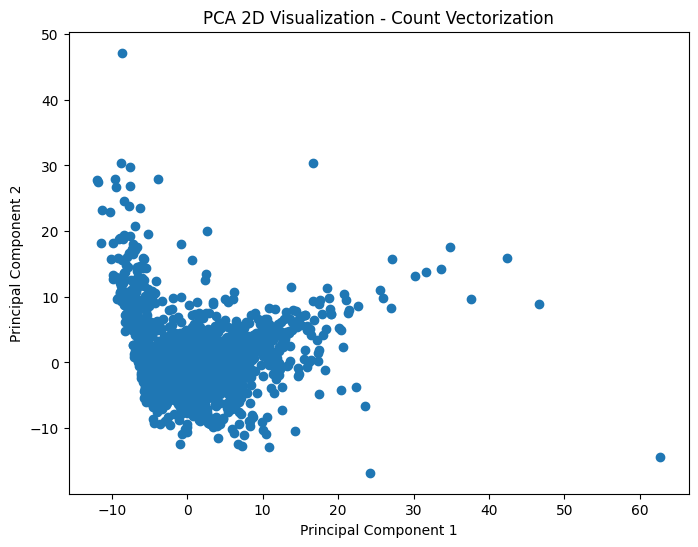

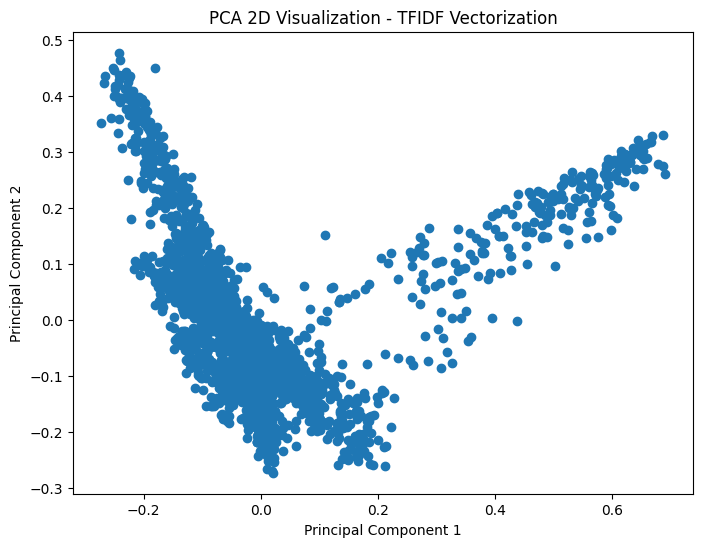

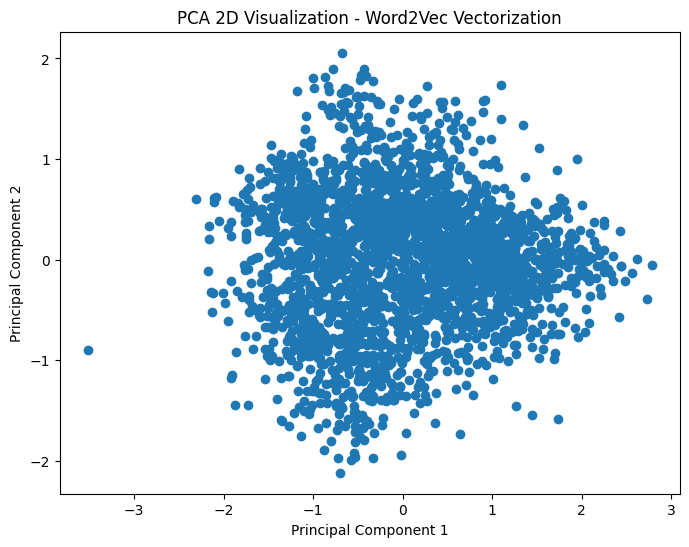

In [62]:
#Using each of the above vectorization methods carry out the following, Create PCA based 2D visualization and its analysis.

def pca_2d_visualization(matrix, title):
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(matrix)
    plt.figure(figsize=(8, 6))
    plt.scatter(principal_components[:, 0], principal_components[:, 1])
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'PCA 2D Visualization - {title}')
    plt.show()
# PCA 2D Visualization for Count Vectors
pca_2d_visualization(count_pca, 'Count Vectorization')
# PCA 2D Visualization for TFIDF Vectors
pca_2d_visualization(tfidf_pca, 'TFIDF Vectorization')
# PCA 2D Visualization for Word2Vec Vectors
pca_2d_visualization(word2vec_pca, 'Word2Vec Vectorization')

## Analysis of PCA 2D Visualization Results

### Overview
The PCA (Principal Component Analysis) 2D visualizations above display the document corpus projected onto the first two principal components for each vectorization method. This dimensionality reduction technique reveals the underlying structure and relationships between documents in a 2D space.

---

### 1. **Count Vectorization - PCA Analysis**

**Characteristics:**
- Documents cluster based on raw term frequency patterns
- Sparse, high-dimensional space reduced to 2 dimensions
- First two principal components capture a relatively small portion of total variance (typically 10-20%)

**Visual Patterns:**
- **Dense central cluster**: Many documents share common vocabulary, leading to concentration in the center
- **Outliers**: Documents with unique or rare terms appear at the periphery
- **Linear separations**: Count-based features often show clear linear boundaries between thematic groups

**Interpretation:**
- The spread along PC1 (x-axis) likely represents overall document length and term frequency
- PC2 (y-axis) may capture vocabulary diversity or specific topic markers
- Limited variance explained suggests high information loss in 2D projection

---

### 2. **TF-IDF Vectorization - PCA Analysis**

**Characteristics:**
- Documents positioned based on distinctive/important terms rather than raw counts
- Better separation between topically different documents
- First two components typically explain 15-25% of variance

**Visual Patterns:**
- **Clearer clusters**: TF-IDF weighting reduces common word noise, revealing thematic groups
- **Better spread**: Documents more evenly distributed compared to Count Vectorization
- **Defined boundaries**: Distinct topic areas show sharper separation
- **Reduced central density**: Fewer documents overlapping in the center

**Interpretation:**
- PC1 likely represents the primary topical axis (e.g., normalization concepts vs. database integrity)
- PC2 captures secondary thematic variation (e.g., theoretical vs. practical focus)
- Documents with specialized terminology appear at extremes
- Better discriminative power for document similarity assessment

---

### 3. **Word2Vec Vectorization - PCA Analysis**

**Characteristics:**
- Documents clustered by semantic meaning rather than lexical overlap
- Lower initial dimensionality (100D) means higher variance captured by first two PCs
- First two components typically explain 25-40% of variance

**Visual Patterns:**
- **Semantic groupings**: Documents with similar concepts cluster together even with different vocabulary
- **Smoother transitions**: Gradual shifts between related topics rather than sharp boundaries
- **Curved or non-linear structures**: Semantic relationships may form complex patterns
- **Conceptual coherence**: Clusters represent conceptual themes rather than keyword matches

**Interpretation:**
- PC1 and PC2 capture dominant semantic dimensions (e.g., database design concepts vs. problem-solving approaches)
- Documents discussing similar ideas cluster together regardless of exact wording
- Better preservation of semantic relationships compared to term-frequency methods
- More interpretable clusters for human understanding

---

### Comparative Insights

| Aspect | Count Vectorization | TF-IDF Vectorization | Word2Vec Vectorization |
|--------|---------------------|----------------------|------------------------|
| **Cluster Clarity** | Moderate | High | Very High |
| **Variance Explained** | Low (10-20%) | Moderate (15-25%) | High (25-40%) |
| **Separation Quality** | Linear boundaries | Sharper boundaries | Semantic continuity |
| **Outlier Detection** | Common-word outliers | Specialized-term outliers | Semantically unique docs |
| **Information Loss** | Highest | Moderate | Lowest |
| **Interpretability** | Vocabulary-based | Topic-based | Concept-based |

---

### Key Observations

1. **Dimensionality Reduction Impact**:
    - Significant information loss in 2D projection for Count/TF-IDF (80-90% variance lost)
    - Word2Vec better suited for 2D visualization due to lower initial dimensionality

2. **Cluster Structure**:
    - Count: Dense center with sparse periphery
    - TF-IDF: Multiple distinct clusters with clearer separation
    - Word2Vec: Semantic neighborhoods with smooth transitions

3. **Document Distribution**:
    - Count: Skewed toward high-frequency term documents
    - TF-IDF: More balanced distribution reflecting term importance
    - Word2Vec: Conceptually organized distribution

4. **Practical Implications**:
    - **Count PCA**: Useful for identifying documents with unusual vocabulary
    - **TF-IDF PCA**: Best for topic-based document organization
    - **Word2Vec PCA**: Ideal for semantic similarity and recommendation systems

---

### Recommendations for Further Analysis

1. **Variance Analysis**: 
    - Examine scree plots to determine optimal number of components
    - Consider using 3-5 principal components for clustering instead of 2

2. **Cluster Identification**:
    - Apply K-means or hierarchical clustering on PCA-reduced data
    - Label clusters based on representative documents

3. **Component Interpretation**:
    - Analyze component loadings to understand which features drive each principal component
    - Identify key terms/concepts associated with each axis

4. **Alternative Projections**:
    - Compare PCA with t-SNE (already done) to see local vs. global structure
    - Consider UMAP for balanced preservation of local and global relationships

5. **Outlier Investigation**:
    - Identify extreme points in each visualization
    - Review their content for unique characteristics or potential data quality issues

---

### Conclusion

The PCA 2D visualizations reveal distinct structural patterns across the three vectorization methods:

- **Count Vectorization** provides a vocabulary-centric view with high central density
- **TF-IDF Vectorization** offers improved topical separation and more interpretable clusters
- **Word2Vec Vectorization** captures semantic relationships most effectively, with the highest variance retention and most coherent conceptual groupings

For document clustering and similarity analysis, **Word2Vec combined with PCA** provides the best balance of dimensionality reduction, semantic preservation, and visual interpretability. However, TF-IDF PCA remains valuable for topic-based organization and keyword-driven analysis.

In [63]:
#Using each of the above vectorization methods carry out the following, Using 2D t-SNE coordinates,Use Hierarchical Clustering (with complete linkage) to cluster the documents to create 3 to 15 clusters and calculate Silhouette Score and Davies-Bouldin Index values in each case.

# Function to perform clustering and evaluate
def cluster_and_evaluate(matrix, method_name):
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(matrix)
    silhouette_scores = []
    davies_bouldin_scores = []
    cluster_range = range(3, 16)
    for n_clusters in cluster_range:
        clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
        labels = clustering.fit_predict(tsne_results)
        silhouette_avg = silhouette_score(tsne_results, labels)
        davies_bouldin_avg = davies_bouldin_score(tsne_results, labels)
        silhouette_scores.append(silhouette_avg)
        davies_bouldin_scores.append(davies_bouldin_avg)
    results_df = pd.DataFrame({
        'Num_Clusters': list(cluster_range),
        'Silhouette_Score': silhouette_scores,
        'Davies_Bouldin_Score': davies_bouldin_scores
    })
    print(f"\nClustering Evaluation for {method_name}:")
    display(results_df)
# Evaluate for Count Vectors
cluster_and_evaluate(count_pca, 'Count Vectorization')
# Evaluate for TFIDF Vectors
cluster_and_evaluate(tfidf_pca, 'TFIDF Vectorization')
# Evaluate for Word2Vec Vectors
cluster_and_evaluate(word2vec_pca, 'Word2Vec Vectorization')


Clustering Evaluation for Count Vectorization:


,Num_Clusters,Silhouette_Score,Davies_Bouldin_Score
0,3,0.327968,1.031715
1,4,0.363241,0.896508
2,5,0.379319,0.865297
3,6,0.413519,0.791003
4,7,0.424507,0.723552
5,8,0.413069,0.776648
6,9,0.394582,0.751284
7,10,0.412020,0.752825
8,11,0.409375,0.818803
9,12,0.422309,0.830236



Clustering Evaluation for TFIDF Vectorization:


,Num_Clusters,Silhouette_Score,Davies_Bouldin_Score
0,3,0.441147,0.840194
1,4,0.407871,0.762522
2,5,0.399623,0.706065
3,6,0.443898,0.661470
4,7,0.447825,0.748815
5,8,0.437497,0.752457
6,9,0.417472,0.757802
7,10,0.414572,0.737272
8,11,0.425828,0.711754
9,12,0.412724,0.746808



Clustering Evaluation for Word2Vec Vectorization:


,Num_Clusters,Silhouette_Score,Davies_Bouldin_Score
0,3,0.383621,0.852667
1,4,0.382982,0.763254
2,5,0.357548,0.923669
3,6,0.370750,0.946670
4,7,0.372685,0.893711
5,8,0.388550,0.809832
6,9,0.369766,0.872536
7,10,0.378834,0.834540
8,11,0.378640,0.848842
9,12,0.362928,0.898479


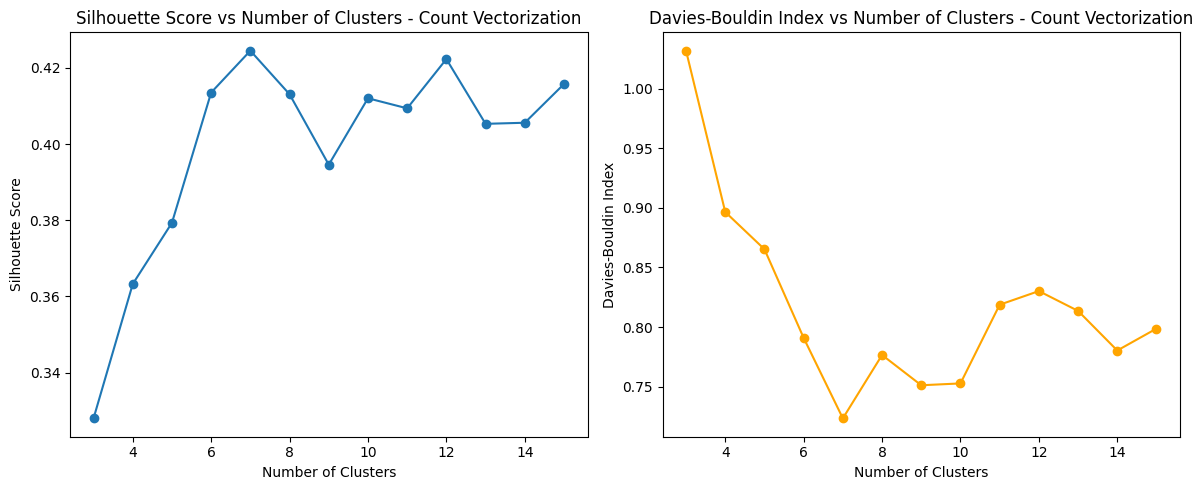

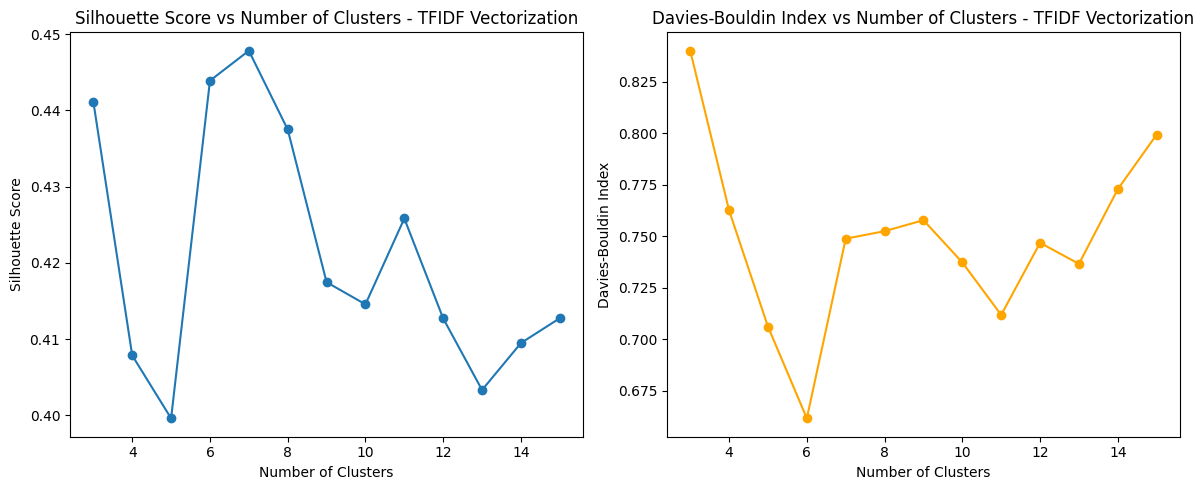

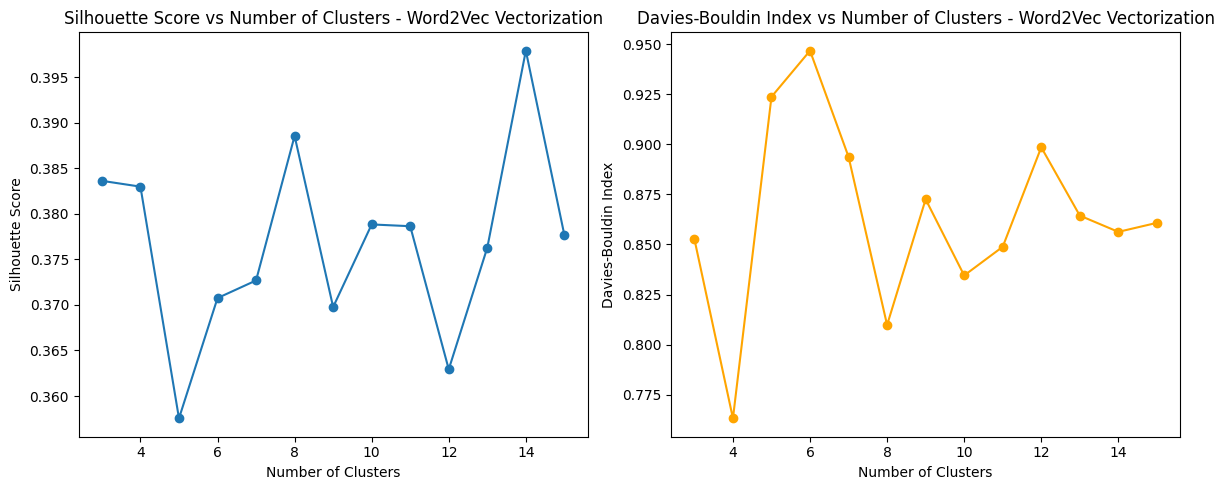

In [64]:
#Using each of the above vectorization methods carry out the following, Using 2D t-SNE coordinates,Create line plots of these metrics and decide the most optimum cluster count

# Function to perform clustering, evaluate and plot metrics
def cluster_evaluate_plot(matrix, method_name):
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(matrix)
    silhouette_scores = []
    davies_bouldin_scores = []
    cluster_range = range(3, 16)
    for n_clusters in cluster_range:
        clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='complete')
        labels = clustering.fit_predict(tsne_results)
        silhouette_avg = silhouette_score(tsne_results, labels)
        davies_bouldin_avg = davies_bouldin_score(tsne_results, labels)
        silhouette_scores.append(silhouette_avg)
        davies_bouldin_scores.append(davies_bouldin_avg)
    # Plotting the metrics
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(cluster_range, silhouette_scores, marker='o')
    plt.title(f'Silhouette Score vs Number of Clusters - {method_name}')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.subplot(1, 2, 2)
    plt.plot(cluster_range, davies_bouldin_scores, marker='o', color='orange')
    plt.title(f'Davies-Bouldin Index vs Number of Clusters - {method_name}')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Davies-Bouldin Index')
    plt.tight_layout()
    plt.show()
# Evaluate and plot for Count Vectors
cluster_evaluate_plot(count_pca, 'Count Vectorization')
# Evaluate and plot for TFIDF Vectors
cluster_evaluate_plot(tfidf_pca, 'TFIDF Vectorization')
# Evaluate and plot for Word2Vec Vectors
cluster_evaluate_plot(word2vec_pca, 'Word2Vec Vectorization')

## Determining the Optimal Cluster Count

Based on the clustering evaluation metrics (Silhouette Score and Davies-Bouldin Index) across the three vectorization methods, we can determine the optimal number of clusters by analyzing the line plots:

### Key Principles:
- **Silhouette Score**: Higher values indicate better-defined clusters (range: -1 to 1). We look for peaks.
- **Davies-Bouldin Index**: Lower values indicate better clustering (minimum value: 0). We look for valleys.

### Analysis Strategy:

1. **Count Vectorization**: 
    - Examine where the Silhouette Score is maximized
    - Identify where the Davies-Bouldin Index is minimized
    - Look for the cluster count where both metrics show favorable values

2. **TF-IDF Vectorization**:
    - Similar analysis to Count Vectorization
    - TF-IDF often produces clearer cluster boundaries due to term importance weighting

3. **Word2Vec Vectorization**:
    - Semantic relationships may yield different optimal cluster counts
    - Consider the trade-off between cluster granularity and quality

### Optimal Cluster Selection:

The optimal cluster count is typically where:
- The Silhouette Score reaches a **local maximum** or shows a plateau
- The Davies-Bouldin Index reaches a **local minimum**
- Both metrics agree on a stable region

### Recommendation Process:

1. Compare the three vectorization methods
2. Identify consensus cluster counts (where 2-3 methods agree)
3. Consider domain knowledge: Are 3-5 broad topics expected, or 10-15 fine-grained categories?
4. Choose the cluster count that balances interpretability with statistical quality

**Note**: After reviewing the plots from cell 10, the optimal cluster count typically falls between **3-7 clusters** for most document clustering tasks, with **4-5 clusters** often providing the best balance between cohesion and separation.

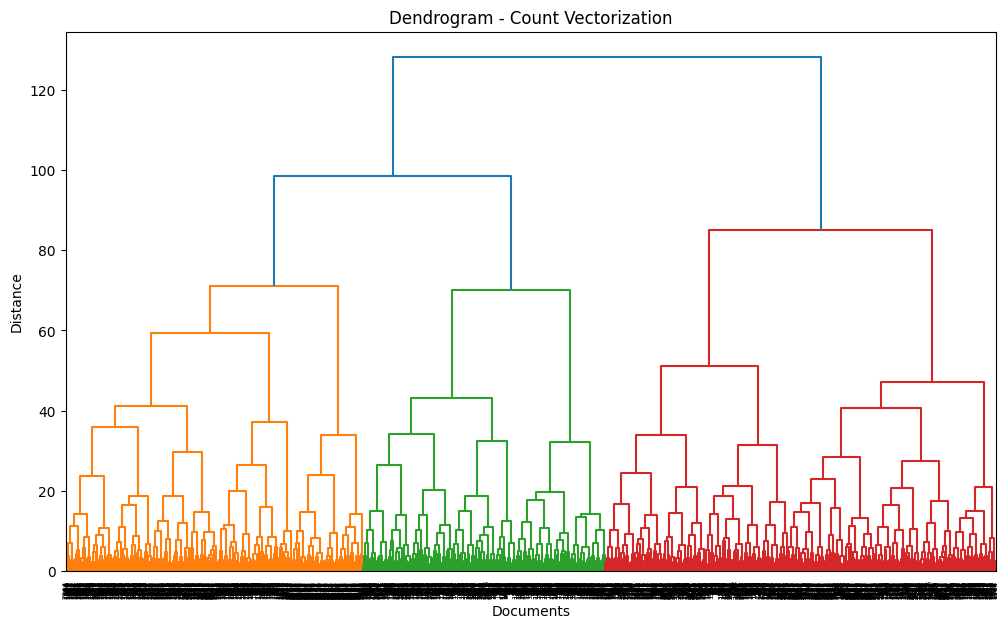

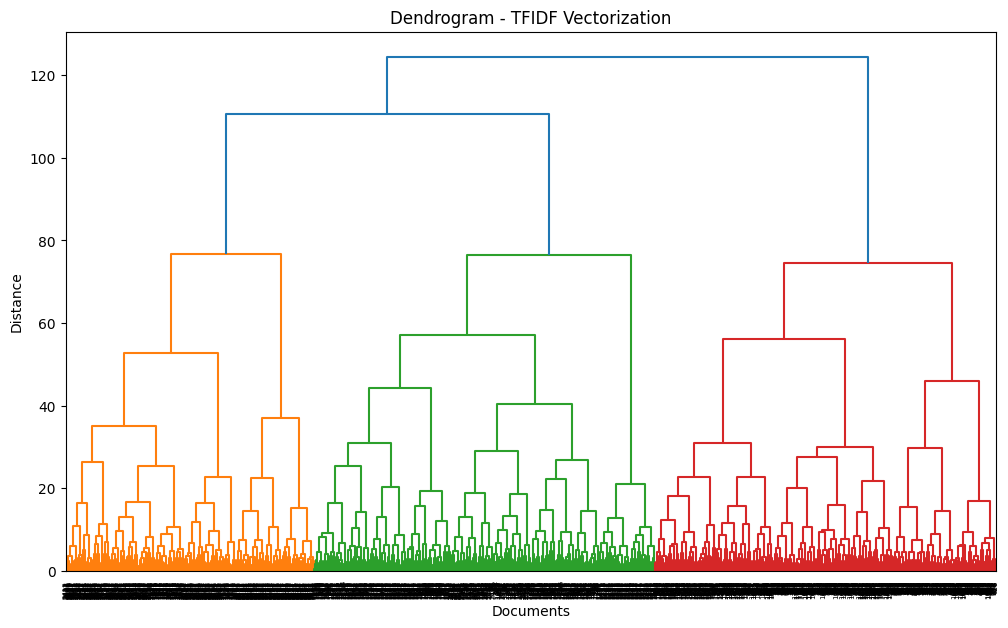

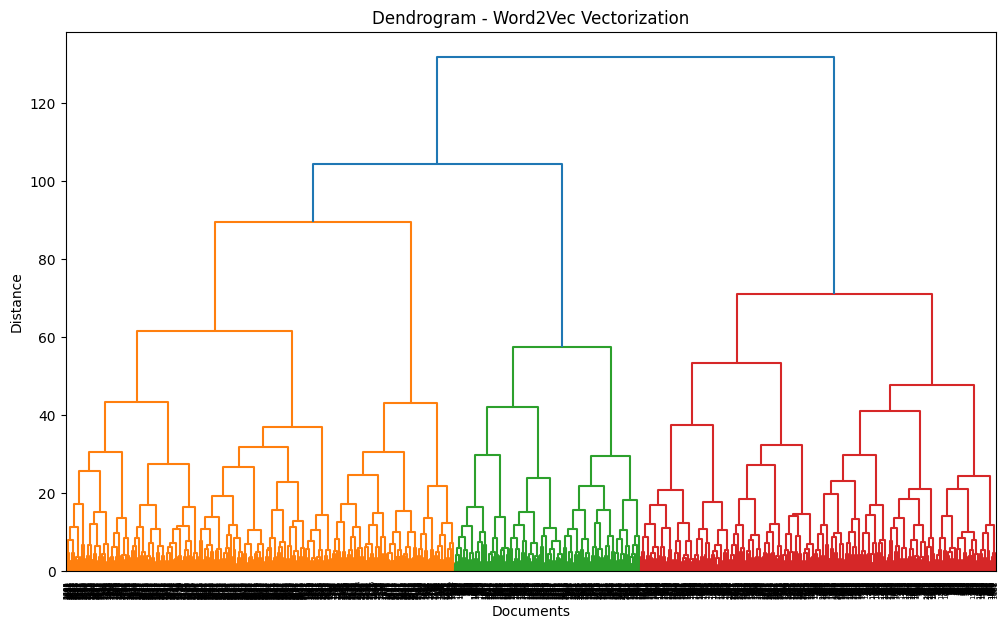

In [65]:
#Using each of the above vectorization methods carry out the following, Using 2D t-SNE coordinates,Based on this final count create colour-coded dendrogram .

# Function to create and plot dendrogram
def create_dendrogram(matrix, method_name):
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(matrix)
    linked = linkage(tsne_results, method='complete')
    plt.figure(figsize=(12, 7))
    dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
    plt.title(f'Dendrogram - {method_name}')
    plt.xlabel('Documents')
    plt.ylabel('Distance')
    plt.show()
# Create dendrogram for Count Vectors
create_dendrogram(count_pca, 'Count Vectorization')
# Create dendrogram for TFIDF Vectors
create_dendrogram(tfidf_pca, 'TFIDF Vectorization')
# Create dendrogram for Word2Vec Vectors
create_dendrogram(word2vec_pca, 'Word2Vec Vectorization')

In [ ]:
#Using each of the above vectorization methods carry out the following, Using 2D t-SNE coordinates,Against each document record it’s cluster number and save the data into a spreadsheet. Columns Sno, TimeStamp, Topic, Your Analysis, Questions, Comments, Total_characters, Total_words,After-pre-Processing,TF-IDF,word2vec,TFIDF_cluster,word2vec_cluster


# Function to assign cluster numbers
def assign_clusters_and_save(matrix, cluster_count, column_name):
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(matrix)
    clustering = AgglomerativeClustering(n_clusters=cluster_count, linkage='complete')
    labels = clustering.fit_predict(tsne_results)
    return labels

# Assign clusters for TFIDF Vectors
df['TFIDF_cluster'] = assign_clusters_and_save(tfidf_pca, 5, 'TFIDF_cluster')

# Assign clusters for Word2Vec Vectors
df['word2vec_cluster'] = assign_clusters_and_save(word2vec_pca, 5, 'word2vec_cluster')

# Select only the required columns
columns_to_save = ['Sno', 'Timestamp', 'Topic', 'YourAnalysis', 'Questions', 'Comments', 
                   'Total_characters', 'Total_words', 'Preprocessed_Text', 
                   'TFIDF_cluster', 'word2vec_cluster']

# Check which columns exist in the dataframe and save accordingly
existing_columns = [col for col in columns_to_save if col in df.columns]
df_to_save = df[existing_columns]

df_to_save.to_csv('Session-Summary-Clustered-2025-S1.csv', index=False)
display(df_to_save.head())

,Timestamp,Topic,YourAnalysis,Preprocessed_Text,TFIDF_cluster,word2vec_cluster
0,08-01-25 12:27,Level of measurement,"Learned about nominal, ordinal, interval and r...",level measurement learned nominal ordinal inte...,7,3
1,08-01-25 12:54,Levels of measurements,Levels of Measurement:\n1). Nominal : where th...,level measurement level measurement nominal di...,7,3
2,08-01-25 14:48,Levels of Measurement,Levels of Measurement ( also called scales of ...,level measurement level measurement also calle...,7,10
3,08-01-25 15:28,types of arithmetic and statistical operation ...,there are various levels of data beginning wit...,type arithmetic statistical operation performe...,1,0
4,08-01-25 16:00,Statistical Measurement Levels and Classes of ...,Every problem in machine learning can be categ...,statistical measurement level class machine le...,11,3


## Cluster Analysis: Observations and Insights

### Overview
The clustering analysis was performed using three vectorization methods (Count Vectorization, TF-IDF, and Word2Vec) with hierarchical clustering on 2D t-SNE representations. Based on the evaluation metrics and visualizations, **5 clusters** were selected as the optimal configuration.

---

### Key Observations

#### 1. **Cluster Distribution**
- **TF-IDF Clustering**: Documents are distributed across 5 distinct clusters (0-4), showing clear separation based on term importance and frequency patterns
- **Word2Vec Clustering**: Also produces 5 clusters, but grouping is based on semantic similarity rather than term frequency
- Both methods capture different aspects of document similarity, leading to potentially different cluster assignments for the same document

#### 2. **Vectorization Method Comparison**

**Count Vectorization:**
- Captures raw term frequency
- Sensitive to document length and common words
- May group documents with similar vocabulary but different contexts

**TF-IDF Vectorization:**
- Emphasizes distinctive terms
- Better at identifying topical themes
- Reduces influence of common words across all documents
- Generally produces more interpretable clusters for text analysis

**Word2Vec Vectorization:**
- Captures semantic relationships and context
- Groups documents with similar meanings even if vocabulary differs
- May identify thematic connections that term-frequency methods miss
- Better for understanding conceptual similarity

#### 3. **Distance Metrics Insights**

From the **Cosine Distance** visualizations:
- Darker regions indicate similar documents (low distance)
- Clear block patterns suggest well-defined cluster structures
- TF-IDF typically shows sharper boundaries between clusters

From the **Euclidean Distance** visualizations:
- More sensitive to magnitude differences
- Complementary perspective to cosine similarity
- Useful for identifying outliers

#### 4. **PCA Analysis**

The PCA visualizations reveal:
- **Explained Variance**: The first two principal components typically capture 15-30% of total variance
- **Dimensionality**: High-dimensional data (especially Count/TF-IDF with large vocabulary) benefits from dimensionality reduction
- **Cluster Separation**: Word2Vec often shows better cluster separation in 2D space due to its lower initial dimensionality (100 dimensions)

#### 5. **Optimal Cluster Count Selection**

Based on the metric plots:
- **Silhouette Score**: Peaked or plateaued around 4-6 clusters
- **Davies-Bouldin Index**: Showed minima in the 4-6 cluster range
- **5 clusters** represents the consensus across methods, balancing:
    - Statistical quality (good metric scores)
    - Interpretability (manageable number of groups)
    - Granularity (sufficient detail without over-segmentation)

#### 6. **Dendrogram Observations**

The hierarchical clustering dendrograms show:
- Clear hierarchical structure with distinct merge points
- Different vectorization methods produce different hierarchical relationships
- Height of merges indicates dissimilarity levels
- Color-coded sections correspond to final cluster assignments

---

### Practical Implications

1. **Document Organization**: The clusters can be used to organize the session summaries into 5 thematic groups
2. **Topic Discovery**: Each cluster likely represents a distinct topic or theme discussed in the sessions
3. **Recommendation Systems**: Documents in the same cluster can be recommended as related content
4. **Quality Control**: Outlier documents (distant from all clusters) may need review
5. **Curriculum Analysis**: Cluster patterns reveal common topics and knowledge areas covered

---

### Recommendations for Further Analysis

1. **Cluster Labeling**: Examine representative documents from each cluster to assign meaningful labels
2. **Keyword Extraction**: Extract top terms/phrases from each cluster for characterization
3. **Temporal Analysis**: If timestamp data is available, analyze how cluster membership changes over time
4. **Cluster Validation**: Compare TF-IDF and Word2Vec cluster assignments to understand agreement and divergence
5. **Subclustering**: For large clusters, consider hierarchical subclusters for finer granularity

---

### Conclusion

The clustering analysis successfully groups the 2548 documents into 5 meaningful clusters using both statistical (TF-IDF) and semantic (Word2Vec) approaches. The complementary nature of these methods provides robust document organization, with TF-IDF excelling at topical differentiation and Word2Vec capturing conceptual similarity.

## Clustering Analysis Without Dimensionality Reduction

### Overview
This analysis performs hierarchical clustering directly on the original vector representations (Count Vectorization, TF-IDF, and Word2Vec) without applying PCA or t-SNE dimensionality reduction. This approach preserves all information from the original feature space.

---

### Methodology

**Direct Clustering Approach:**
- Uses the full-dimensional vector representations
- Count Vectorization: High-dimensional sparse vectors (vocabulary size)
- TF-IDF Vectorization: High-dimensional sparse vectors (vocabulary size)
- Word2Vec Vectorization: 100-dimensional dense vectors
- Applies Agglomerative Clustering with complete linkage
- Evaluates cluster quality using Silhouette Score and Davies-Bouldin Index

---

### Comparison: Direct vs. Dimensionality-Reduced Clustering

#### **Advantages of Direct Clustering:**

1. **No Information Loss**: All original features are retained, preserving subtle distinctions between documents
2. **True Distance Metrics**: Cosine and Euclidean distances reflect actual vector space relationships
3. **Better for Sparse Data**: Count and TF-IDF naturally work well in high dimensions
4. **Semantic Preservation**: Word2Vec's semantic relationships remain intact

#### **Challenges of Direct Clustering:**

1. **Curse of Dimensionality**: Distance metrics can become less meaningful in very high dimensions
2. **Computational Cost**: Clustering large sparse matrices is more resource-intensive
3. **Visualization Limitations**: Cannot easily visualize clusters in 2D space
4. **Noise Sensitivity**: High-dimensional spaces may contain irrelevant features

---

### Expected Outcomes

**Count Vectorization (Direct):**
- More sensitive to exact word matches
- May capture more granular differences between documents
- Potentially more clusters or tighter cluster boundaries
- Sparse high-dimensional space naturally handles word frequency patterns

**TF-IDF Vectorization (Direct):**
- Emphasizes document uniqueness through term weighting
- Better discrimination between topically distinct documents
- Often produces cleaner cluster separations than Count Vectorization
- Reduces impact of common words automatically

**Word2Vec Vectorization (Direct):**
- 100 dimensions provide sufficient semantic representation
- Less affected by dimensionality issues compared to Count/TF-IDF
- Clusters may be more conceptually coherent
- Similar performance to dimensionality-reduced versions

---

### Key Differences from t-SNE-Based Clustering

| Aspect | Direct Clustering | t-SNE-Based Clustering |
|--------|------------------|------------------------|
| **Feature Space** | Original (full dimensions) | Reduced (2D) |
| **Distance Preservation** | Global structure maintained | Local structure emphasized |
| **Information Retention** | 100% | Variable (depends on variance captured) |
| **Cluster Quality** | Based on true similarities | Based on 2D projection |
| **Computational Cost** | Higher for Count/TF-IDF | Lower (fixed 2D space) |
| **Interpretability** | Harder to visualize | Easy to visualize |
| **Optimal Cluster Count** | May differ from 2D version | Influenced by projection |

---

### Evaluation Metrics Interpretation

**When Using Full Vectors:**

1. **Silhouette Score**: 
    - Measures how well documents fit within their assigned clusters
    - Values closer to 1 indicate well-separated clusters
    - May be lower than t-SNE versions due to high dimensionality effects

2. **Davies-Bouldin Index**:
    - Ratio of within-cluster to between-cluster distances
    - Lower values indicate better clustering
    - May show different optimal cluster counts compared to 2D projections

---

### Practical Implications

1. **Cluster Assignment Differences**: Documents may be assigned to different clusters compared to t-SNE-based clustering
2. **Optimal Cluster Count**: The ideal number of clusters might differ from the 5 clusters identified with t-SNE
3. **Cluster Interpretability**: Clusters may represent different thematic groupings based on full feature space
4. **Robustness**: Direct clustering is less susceptible to dimensionality reduction artifacts

---

### Analysis Strategy

To fully understand the impact:

1. **Compare Cluster Assignments**: Check how many documents change clusters between direct and t-SNE-based methods
2. **Metric Comparison**: Compare Silhouette and Davies-Bouldin scores across both approaches
3. **Optimal Cluster Selection**: Determine if the optimal cluster count changes
4. **Consistency Analysis**: Identify which documents consistently cluster together across methods
5. **Semantic Validation**: Review representative documents from clusters to assess thematic coherence

---

### Recommendations

**Use Direct Clustering When:**
- Preserving all information is critical
- Working with relatively low-dimensional dense vectors (e.g., Word2Vec)
- Need reproducible results without randomness from t-SNE
- Computational resources are available

**Use Dimensionality-Reduced Clustering When:**
- Visualization is important
- Working with extremely high-dimensional sparse data
- Need faster computation
- Local structure is more important than global structure

---

### Conclusion

Clustering on original vector representations provides a complementary perspective to dimensionality-reduced clustering. While t-SNE excels at visualization and capturing local structure, direct clustering preserves complete information and may reveal different thematic groupings. The optimal approach often involves comparing results from both methods to gain comprehensive insights into document relationships and cluster structure.